# Metabolite Catalog Exploration

**File**: `human_database_merge_unique_metab_with_HMDB_Info.csv`  
**Goal**: Characterize the consolidated, non-redundant metabolite list and assess its coverage, chemical diversity, and database provenance — laying the groundwork for downstream cancer cell-cell communication analysis.

---

## 1. Environment Setup

In [236]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import re
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

In [237]:
# ==========================================
# ⚙️ USER PARAMETERS (Export Options)
# ==========================================
# Full Notebook HTML Report Export Toggle:
# - True  -> Automatically exports the entire notebook (Markdown, Code, Tables, Figures) to styled HTML
# - False -> Disables automatic HTML export
SAVE_AS_HTML = True  # DEFAULT: False. Change to True to export the entire notebook!

## 2. Load Data

In [238]:
data_path = '../output/human_database_merge_unique_metab_with_HMDB_Info.csv'
df = pd.read_csv(data_path)
print(f'Dataset loaded: {len(df):,} unique metabolites, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset loaded: 402 unique metabolites, 12 columns
Columns: ['Metabolite_Name', 'database', 'databases_count', 'HMDB_ID', 'HMDB_Name', 'SMILES', 'INCHIKEY', 'CHEMICAL_FORMULA', 'AVERAGE_MASS', 'MONO_MASS', 'Super_Class', 'Sub_Class']


,Metabolite_Name,database,databases_count,HMDB_ID,HMDB_Name,SMILES,INCHIKEY,CHEMICAL_FORMULA,AVERAGE_MASS,MONO_MASS,Super_Class,Sub_Class
0,(r)-5-diphosphomevalonic acid,"Cellinker2, MEBOCOST, MRCLinkDB",3,HMDB0001090,(R)-5-Diphosphomevalonic acid,C[C@@](O)(CCOP(O)(=O)OP(O)(O)=O)CC(O)=O,SIGQQUBJQXSAMW-ZCFIWIBFSA-N,C6H14O10P2,308.1169,308.006220,Organic oxygen compounds,Organic pyrophosphates
1,(r)-lipoic acid,MetaLigand,1,HMDB0001451,(R)-Lipoic acid,OC(=O)CCCC[C@@H]1CCSS1,AGBQKNBQESQNJD-SSDOTTSWSA-N,C8H14O2S2,206.3260,206.043521,Lipids and lipid-like molecules,NaN
2,"1,25-dihydroxyvitamin d3-26,23-lactone","Cellinker2, MRCLinkDB",2,HMDB0000969,"1,25-Dihydroxyvitamin D3-26,23-lactone",[H][C@@]1(CC[C@@]2([H])\C(CCC[C@]12C)=C\C=C1\C...,WMYIVSWWSRCZFA-RWVJFQLJSA-N,C27H40O5,444.6035,444.287574,Lipids and lipid-like molecules,NaN
3,1-methylhistamine,MetaLigand,1,HMDB0000898,1-Methylhistamine,CN1C=NC(CCN)=C1,FHQDWPCFSJMNCT-UHFFFAOYSA-N,C6H11N3,125.1716,125.095297,Organic acids and derivatives,NaN
4,11-cis-retinol,"Cellinker2, MEBOCOST, MRCLinkDB",3,HMDB0006216,11-cis-Retinol,C\C(=C/CO)\C=C/C=C(\C)/C=C/C1=C(C)CCCC1(C)C,FPIPGXGPPPQFEQ-IOUUIBBYSA-N,C20H30O,286.4516,286.229666,Lipids and lipid-like molecules,Retinoids


## 3. Data Completeness Overview

How complete is each field across the unique metabolites?

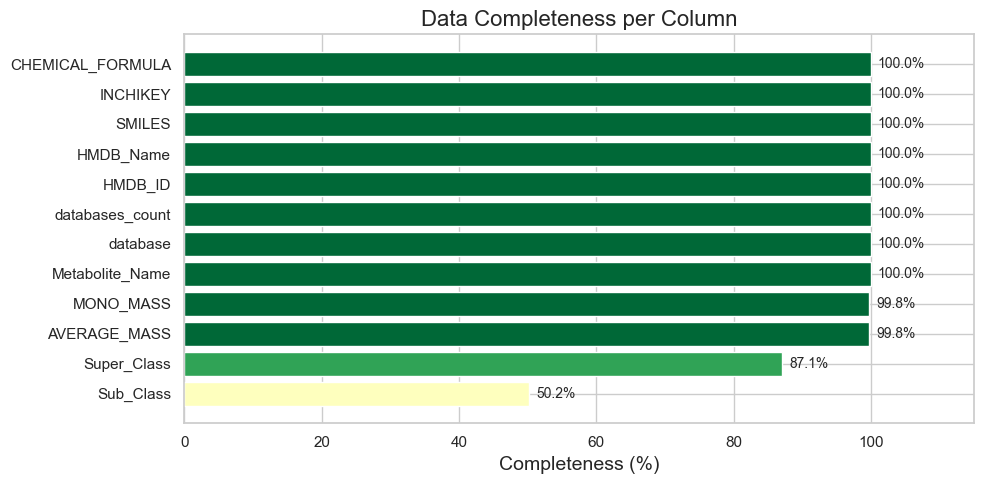

In [239]:
completeness = (df.notna().sum() / len(df) * 100).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(completeness.index, completeness.values, color=plt.cm.RdYlGn(completeness.values / 100))
ax.set_xlabel('Completeness (%)')
ax.set_title('Data Completeness per Column')
for bar, val in zip(bars, completeness.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlim(0, 115)
plt.tight_layout()
plt.show()

---

## 4. Database Provenance

### 4.1. Cross-Database Validation
Metabolites supported by more databases have higher confidence.

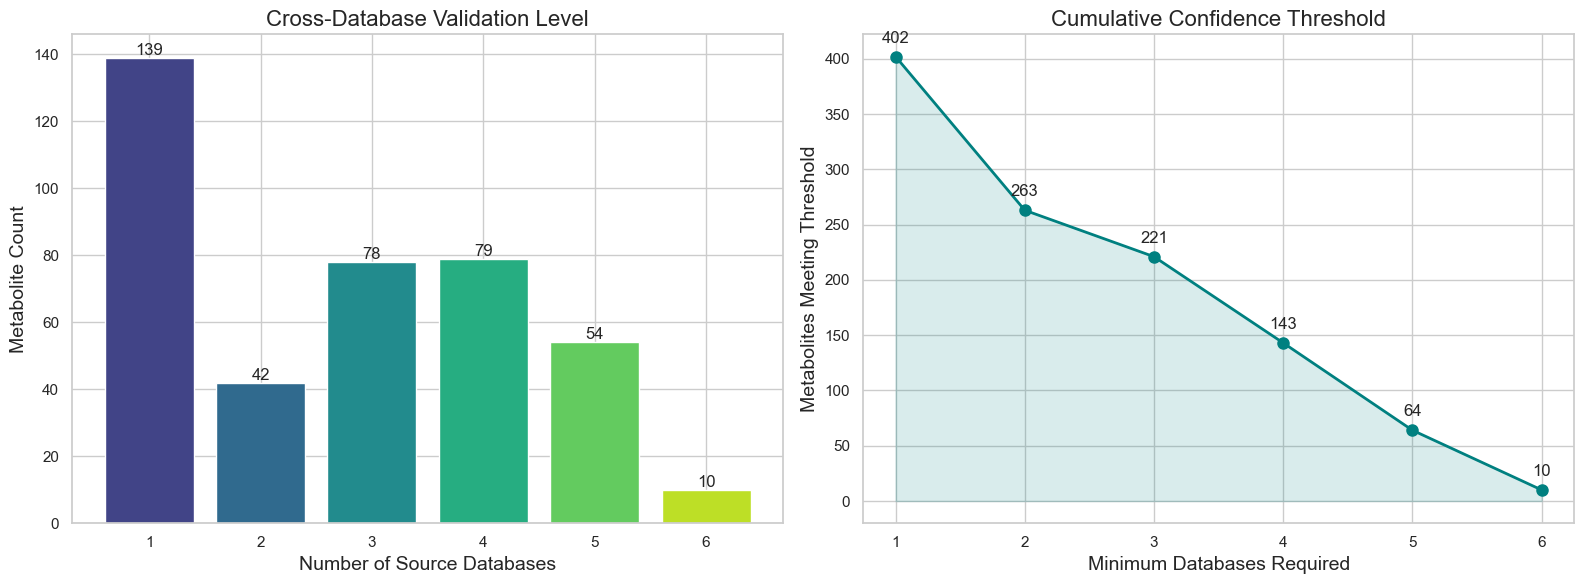


→ 221 metabolites (55.0%) are supported by 3+ databases (high confidence).
→ 139 metabolites (34.6%) are unique to a single database.


In [240]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Count distribution
ax = axes[0]
vc = df['databases_count'].value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(vc)))
bars = ax.bar(vc.index, vc.values, color=colors, edgecolor='white')
for b in bars:
    ax.annotate(f'{int(b.get_height())}', (b.get_x() + b.get_width()/2., b.get_height()),
                ha='center', va='bottom', fontsize=12)
ax.set_xlabel('Number of Source Databases')
ax.set_ylabel('Metabolite Count')
ax.set_title('Cross-Database Validation Level')

# Right: Cumulative confidence
ax2 = axes[1]
cumul = vc.iloc[::-1].cumsum().iloc[::-1]
ax2.plot(cumul.index, cumul.values, 'o-', color='teal', markersize=8, linewidth=2)
ax2.fill_between(cumul.index, cumul.values, alpha=0.15, color='teal')
ax2.set_xlabel('Minimum Databases Required')
ax2.set_ylabel('Metabolites Meeting Threshold')
ax2.set_title('Cumulative Confidence Threshold')
for x, y in zip(cumul.index, cumul.values):
    ax2.annotate(f'{y}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center')

plt.tight_layout()
plt.show()

print(f'\n→ {(df["databases_count"] >= 3).sum()} metabolites ({(df["databases_count"] >= 3).mean()*100:.1f}%) are supported by 3+ databases (high confidence).')
print(f'→ {(df["databases_count"] == 1).sum()} metabolites ({(df["databases_count"] == 1).mean()*100:.1f}%) are unique to a single database.')

In [241]:
print("These are the metabolites mentioned in all 6 databases checked:")
df[(df["databases_count"] >= 6)]

These are the metabolites mentioned in all 6 databases checked:


,Metabolite_Name,database,databases_count,HMDB_ID,HMDB_Name,SMILES,INCHIKEY,CHEMICAL_FORMULA,AVERAGE_MASS,MONO_MASS,Super_Class,Sub_Class
89,androstenedione,"CellPhoneDBv5, Cellinker2, MEBOCOST, MRCLinkDB...",6,HMDB0000053,Androstenedione,[H][C@@]12CCC(=O)[C@@]1(C)CC[C@@]1([H])[C@@]2(...,AEMFNILZOJDQLW-QAGGRKNESA-N,C19H26O2,286.4085,286.193280,Lipids and lipid-like molecules,Androstane steroids
114,cholesterol,"CellPhoneDBv5, Cellinker2, MEBOCOST, MRCLinkDB...",6,HMDB0000067,Cholesterol,[H][C@@]1(CC[C@@]2([H])[C@]3([H])CC=C4C[C@@H](...,HVYWMOMLDIMFJA-DPAQBDIFSA-N,C27H46O,386.6535,386.354866,Lipids and lipid-like molecules,Cholestane steroids
180,estradiol,"CellPhoneDBv5, Cellinker2, MEBOCOST, MRCLinkDB...",6,HMDB0000151,Estradiol,[H][C@@]12CC[C@H](O)[C@@]1(C)CC[C@]1([H])C3=C(...,VOXZDWNPVJITMN-ZBRFXRBCSA-N,C18H24O2,272.3820,272.177630,Lipids and lipid-like molecules,Estrane steroids
209,glycine,"CellPhoneDBv5, Cellinker2, MEBOCOST, MRCLinkDB...",6,HMDB0000123,Glycine,NCC(O)=O,DHMQDGOQFOQNFH-UHFFFAOYSA-N,C2H5NO2,75.0666,75.032028,Organic acids and derivatives,"Amino acids, peptides, and analogues"
220,histamine,"CellPhoneDBv5, Cellinker2, MEBOCOST, MRCLinkDB...",6,HMDB0000870,Histamine,NCCC1=CNC=N1,NTYJJOPFIAHURM-UHFFFAOYSA-N,C5H9N3,111.1451,111.079647,Organic acids and derivatives,Amines
246,l-glutamate,"CellPhoneDBv5, Cellinker2, MEBOCOST, MRCLinkDB...",6,HMDB0000148,Glutamic acid,N[C@@H](CCC(O)=O)C(O)=O,WHUUTDBJXJRKMK-VKHMYHEASA-N,C5H9NO4,147.1293,147.053158,Organic acids and derivatives,"Amino acids, peptides, and analogues"
324,progesterone,"CellPhoneDBv5, Cellinker2, MEBOCOST, MRCLinkDB...",6,HMDB0001830,Progesterone,[H][C@@]12CC[C@H](C(C)=O)[C@@]1(C)CC[C@@]1([H]...,RJKFOVLPORLFTN-LEKSSAKUSA-N,C21H30O2,314.4617,314.224580,Lipids and lipid-like molecules,Pregnane steroids
349,serotonin,"CellPhoneDBv5, Cellinker2, MEBOCOST, MRCLinkDB...",6,HMDB0000259,Serotonin,NCCC1=CNC2=C1C=C(O)C=C2,QZAYGJVTTNCVMB-UHFFFAOYSA-N,C10H12N2O,176.2151,176.094963,Organic acids and derivatives,Tryptamines and derivatives
366,testosterone,"CellPhoneDBv5, Cellinker2, MEBOCOST, MRCLinkDB...",6,HMDB0000234,Testosterone,[H][C@@]12CC[C@H](O)[C@@]1(C)CC[C@@]1([H])[C@@...,MUMGGOZAMZWBJJ-DYKIIFRCSA-N,C19H28O2,288.4244,288.208930,Lipids and lipid-like molecules,Androstane steroids
367,testosterone,"CellPhoneDBv5, Cellinker2, MEBOCOST, MRCLinkDB...",6,HMDB0002833,Testosterone sulfate,[H][C@@]12CC[C@H](OS(O)(=O)=O)[C@@]1(C)CC[C@@]...,WAQBISPOEAOCOG-DYKIIFRCSA-N,C19H28O5S,368.4880,368.165745,Lipids and lipid-like molecules,Androstane steroids


### 4.2. Individual Database Contributions

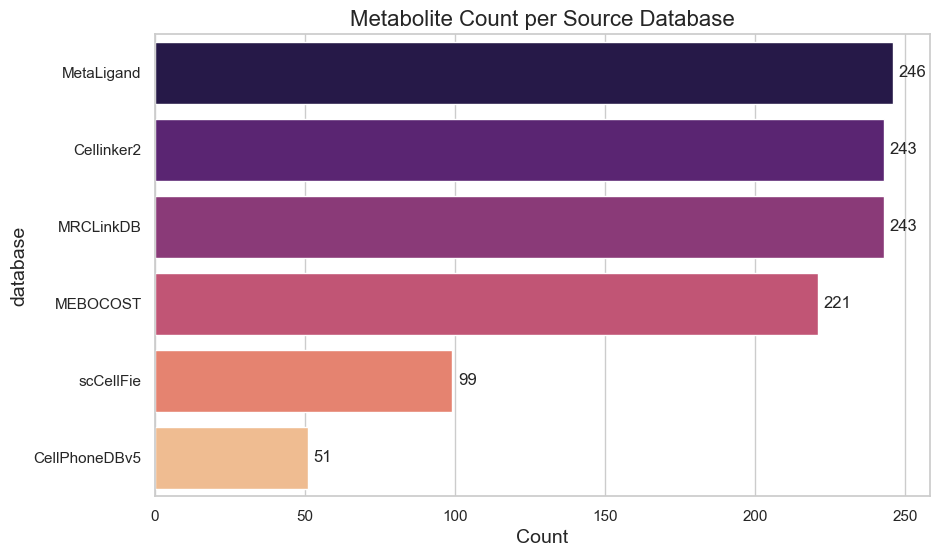

In [242]:
db_series = df['database'].str.split(', ').explode()
db_counts = db_series.value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=db_counts.values, y=db_counts.index, hue=db_counts.index, palette='magma', legend=False)
plt.title('Metabolite Count per Source Database')
plt.xlabel('Count')
for i, v in enumerate(db_counts.values):
    plt.text(v + 2, i, f'{v}', va='center')
plt.show()

#### Note on Cellinker2 and MRCLinkDB Overlap
In the merged dataset, **Cellinker2** and **MRCLinkDB** often show 100% overlap and zero exclusive metabolites in the counts below. This is an expected result of the pipeline logic in `merge_dbs_claude.py`, which identifies metabolites shared between these two sources and combines them into single entries (marked as `MRCLinkDB/Cellinker2`). Consequently, while they both contribute significant data, they appear as a joint set in the unique metabolite mapping.

### 4.3. Pairwise Database Overlap (Co-occurrence Matrix)
Which databases share the most metabolites?

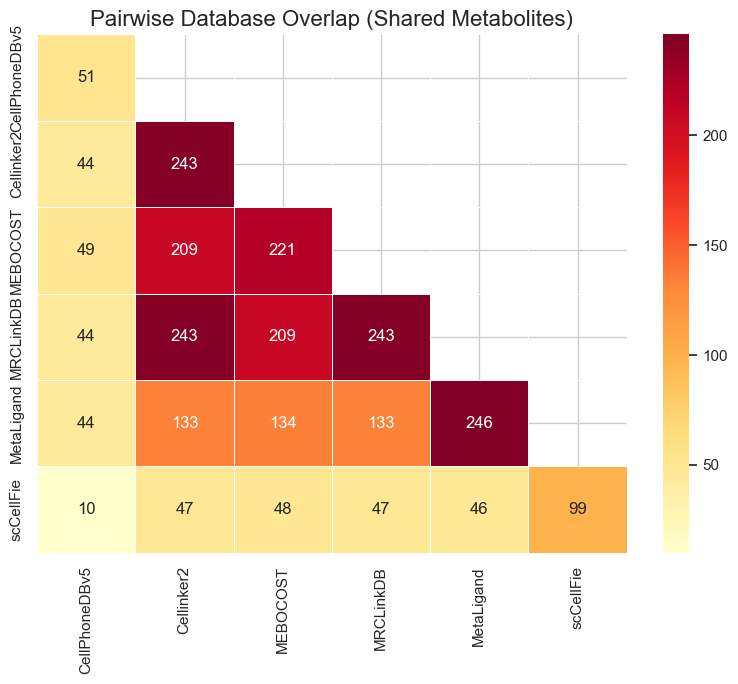


=== Database-Exclusive Metabolites ===
  CellPhoneDBv5: 1 exclusive metabolites
  Cellinker2: 0 exclusive metabolites
  MEBOCOST: 3 exclusive metabolites
  MRCLinkDB: 0 exclusive metabolites
  MetaLigand: 96 exclusive metabolites
  scCellFie: 39 exclusive metabolites


In [243]:
# Build binary presence matrix
db_list = df['database'].str.split(', ')
all_dbs = sorted(db_series.unique())
presence = pd.DataFrame({db: db_list.apply(lambda x: db in x) for db in all_dbs})

# Overlap matrix (cast to int to ensure correct integer counts)
overlap = presence.astype(int).T.dot(presence.astype(int))

# Plot
mask = np.triu(np.ones_like(overlap, dtype=bool), k=1)
plt.figure(figsize=(8, 7))
sns.heatmap(overlap, annot=True, fmt='d', cmap='YlOrRd', mask=mask, linewidths=0.5,
            xticklabels=all_dbs, yticklabels=all_dbs)
plt.title('Pairwise Database Overlap (Shared Metabolites)')
plt.tight_layout()
plt.show()

# Unique metabolites per database
print('\n=== Database-Exclusive Metabolites ===')
for db in all_dbs:
    exclusive = presence[presence[db] & (presence.sum(axis=1) == 1)]
    print(f'  {db}: {len(exclusive)} exclusive metabolites')

---

## 5. HMDB Annotation Coverage

402/402 metabolites have HMDB identifiers.


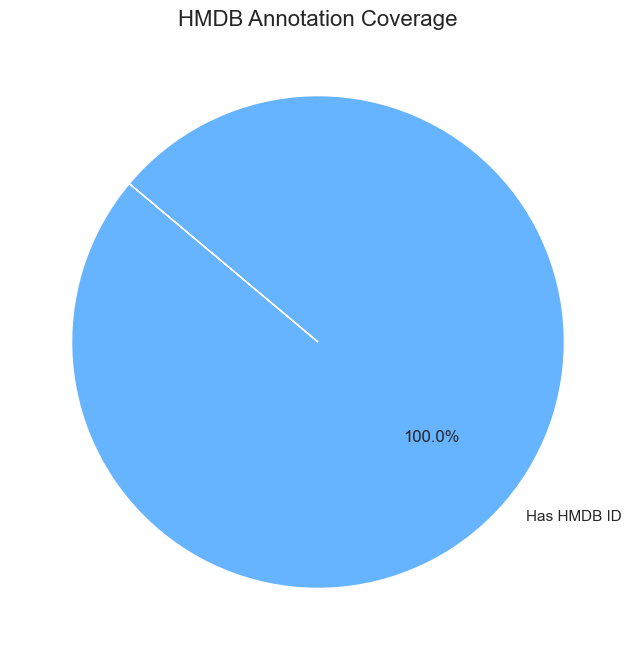

In [244]:
hmdb_counts = df['HMDB_ID'].notna().value_counts()
labels = [('Has HMDB ID' if i else 'Missing HMDB ID') for i in hmdb_counts.index]
explode = [0.05] * len(hmdb_counts) if len(hmdb_counts) > 1 else [0]
print(f'{hmdb_counts.get(True, 0)}/{len(df)} metabolites have HMDB identifiers.')
plt.figure(figsize=(8, 8))
plt.pie(hmdb_counts, labels=labels, autopct='%1.1f%%', 
        startangle=140, colors=['#66b3ff','#ff9999'], explode=explode)
plt.title('HMDB Annotation Coverage')
plt.show()



---

## 6. Chemical Space Characterization

### 6.1. Molecular Weight Distribution
Small molecules (<500 Da) are typical metabolite signaling ligands.

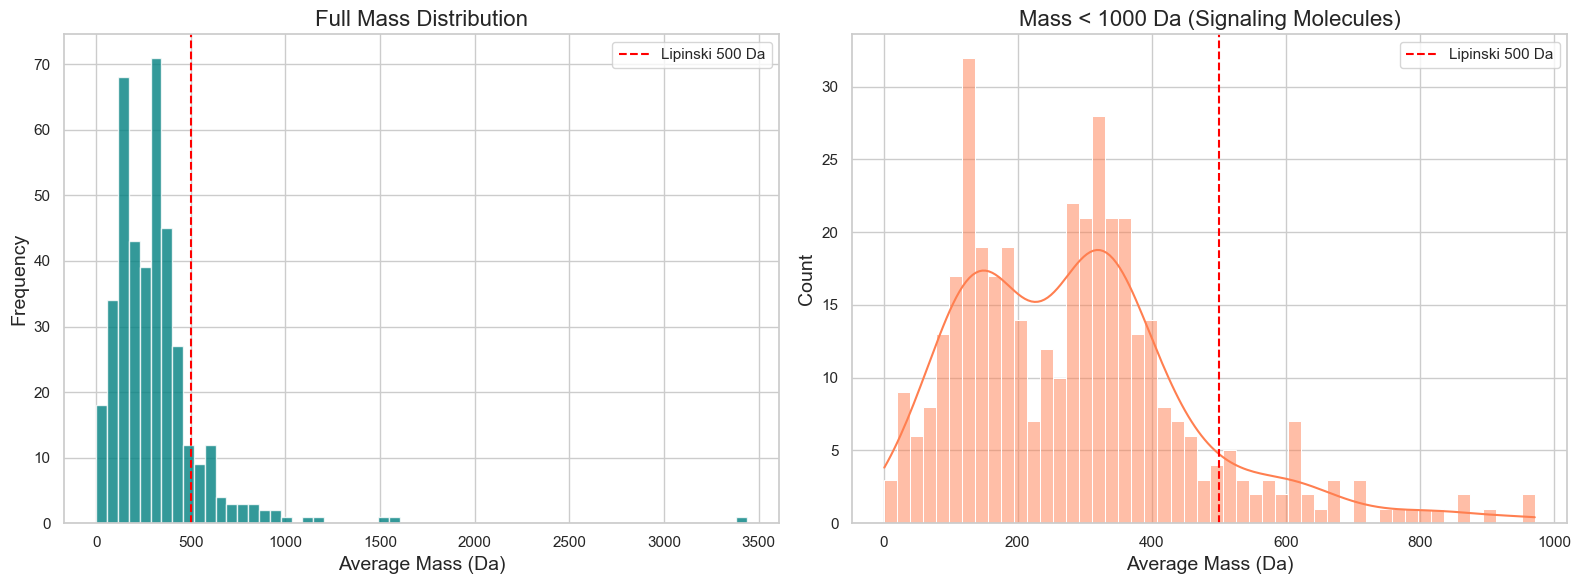


→ 353/401 (88.0%) metabolites are < 500 Da (typical small-molecule ligands).
→ Median mass: 286.5 Da
→ Range: 1.0 – 3438.0 Da


In [245]:
masses = df['AVERAGE_MASS'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full range histogram
ax = axes[0]
ax.hist(masses, bins=60, color='teal', edgecolor='white', alpha=0.8)
ax.axvline(500, color='red', linestyle='--', label='Lipinski 500 Da')
ax.set_xlabel('Average Mass (Da)')
ax.set_ylabel('Frequency')
ax.set_title('Full Mass Distribution')
ax.legend()

# Focused range with KDE
ax2 = axes[1]
sns.histplot(masses[masses < 1000], bins=50, kde=True, color='coral', ax=ax2)
ax2.axvline(500, color='red', linestyle='--', label='Lipinski 500 Da')
ax2.set_xlabel('Average Mass (Da)')
ax2.set_title('Mass < 1000 Da (Signaling Molecules)')
ax2.legend()

plt.tight_layout()
plt.show()

below500 = (masses < 500).sum()
print(f'\n→ {below500}/{len(masses)} ({below500/len(masses)*100:.1f}%) metabolites are < 500 Da (typical small-molecule ligands).')
print(f'→ Median mass: {masses.median():.1f} Da')
print(f'→ Range: {masses.min():.1f} – {masses.max():.1f} Da')

### 6.2. Chemical Superclass Distribution
Exploring the chemical classifications (ClassyFire Superclasses) of the integrated metabolites in MetabConnectomeDB. This classification helps elucidate the diversity of signaling ligands present in the tumor microenvironment (e.g., lipids, organic acids, heterocyclic compounds).

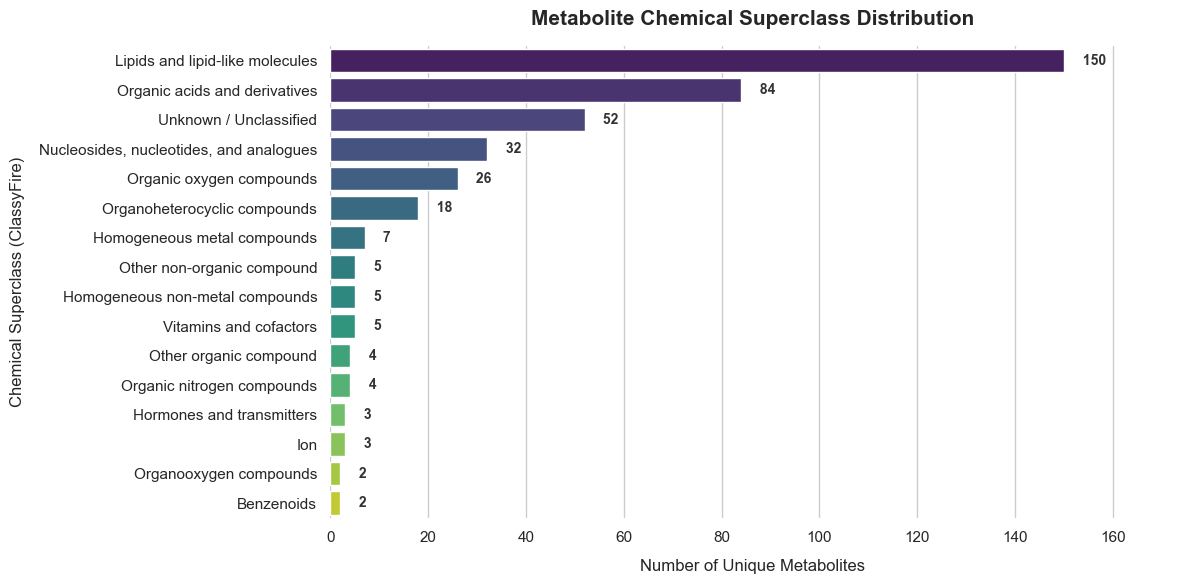

=== Chemical Superclass Breakdown ===
  Lipids and lipid-like molecules     :  150 metabolites (37.3%)
  Organic acids and derivatives       :   84 metabolites (20.9%)
  Unknown / Unclassified              :   52 metabolites (12.9%)
  Nucleosides, nucleotides, and analogues :   32 metabolites (8.0%)
  Organic oxygen compounds            :   26 metabolites (6.5%)
  Organoheterocyclic compounds        :   18 metabolites (4.5%)
  Homogeneous metal compounds         :    7 metabolites (1.7%)
  Other non-organic compound          :    5 metabolites (1.2%)
  Homogeneous non-metal compounds     :    5 metabolites (1.2%)
  Vitamins and cofactors              :    5 metabolites (1.2%)
  Other organic compound              :    4 metabolites (1.0%)
  Organic nitrogen compounds          :    4 metabolites (1.0%)
  Hormones and transmitters           :    3 metabolites (0.7%)
  Ion                                 :    3 metabolites (0.7%)
  Organooxygen compounds              :    2 metabolites (0

In [246]:
# Analyze and plot ClassyFire Superclass distribution
superclass_counts = df['Super_Class'].fillna('Unknown / Unclassified').value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=superclass_counts.values, y=superclass_counts.index, palette='viridis', hue=superclass_counts.index, legend=False)

# Add labels to each bar
for i, v in enumerate(superclass_counts.values):
    plt.text(v + 3, i, f" {v}", va='center', ha='left', fontsize=10, color='#333333', fontweight='semibold')

plt.title('Metabolite Chemical Superclass Distribution', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Number of Unique Metabolites', fontsize=12, labelpad=10)
plt.ylabel('Chemical Superclass (ClassyFire)', fontsize=12, labelpad=10)
sns.despine(left=True, bottom=True)
plt.xlim(0, max(superclass_counts.values) * 1.15)
plt.tight_layout()
plt.show()

print("=== Chemical Superclass Breakdown ===")
for superclass, count in superclass_counts.items():
    print(f"  {superclass:<35} : {count:>4} metabolites ({count/len(df)*100:.1f}%)")

### 🧬 Biological Significance: Chemical Superclasses & the Cancer Connectome

Exploring how different chemical superclasses function within the **Tumor Microenvironment (TME)** is vital for dissecting metabolite-mediated cellular crosstalk. In the cancer connectome, extracellular metabolites do not merely represent metabolic waste or intermediates; they function as active **paracrine and autocrine signaling ligands** that bind to specific receptors (GPCRs, ion channels, nuclear receptors) on cancer cells, immune cells, and endothelial cells.

Here, we outline the primary cancer signaling paradigms and metabolic reprogramming pathways associated with the dominant chemical superclasses in the MetabConnectomeDB catalog:

---

#### 1. 🧪 Lipids and Lipid-like Molecules (37.7% of unique metabolites)
As the largest superclass in the database, lipids play a dual role in tumor progression: serving as membrane building blocks and acting as potent lipid-mediator signaling ligands.
- **Sphingolipid Signaling (e.g., Sphingosine 1-phosphate - S1P):** Active tumor cells and associated stromal cells upregulate Sphingosine Kinase 1 (SPHK1), leading to the secretion of S1P. Extracellular S1P binds to a family of G-protein coupled receptors (**S1PR1–5**), activating downstream PI3K/Akt and MAPK pathways. This drives tumor angiogenesis, cell migration, lymphangiogenesis, and chemotherapy/immunotherapy resistance.
- **Eicosanoid & Prostaglandin Biology (e.g., PGE₂):** Derived from arachidonic acid via the Cyclooxygenase-2 (**COX-2**) pathway, Prostaglandin E₂ ($PGE_2$) is secreted into the TME. $PGE_2$ binds to EP receptors ($EP_{1-4}$), forming a major immune-evasion axis. It directly suppresses cytotoxic CD8⁺ T-cell activation and dendritic cell antigen presentation, while recruiting and activating immunosuppressive regulatory T cells ($T_{reg}$) and Myeloid-Derived Suppressor Cells (MDSCs).
- **Lysophosphatidic Acid (LPA) Axis:** LPA acts as a primary ligand for LPAR1–6 receptors, triggering Rho-ROCK and Ras-MAPK to stimulate tumor cell invasion, cytoskeletal remodeling, and metastatic dissemination.
- **Oxysterols & Nuclear Receptors (e.g., 25-HC):** Cholesterol derivatives, such as 25-hydroxycholesterol (25-HC), bind to Liver X Receptors (LXR) and chemokine GPCRs (like GPR183), coordinating immunosuppressive immune cell chemotaxis and tumor-associated macrophage (TAM) polarization.

---

#### 2. 🧬 Organic Acids and Derivatives (21.1% of unique metabolites)
This class contains amino acids, short-chain fatty acids, and key metabolic byproducts which reprogram both immune cell effector functions and tumor survival.
- **Glutamate Excitotoxicity & Signaling:** Many aggressive cancers (e.g., triple-negative breast cancer, glioblastoma, prostate cancer) upregulate the cystine/glutamate antiporter **xCT** ($SLC7A11$) to import cystine for glutathione synthesis, exporting massive amounts of glutamate into the extracellular space. Extracellular glutamate acts as a signaling ligand on metabotropic ($mGluRs$) and ionotropic ($iGluRs$) glutamate receptors, promoting tumor survival, proliferation, and driving tumor-induced excitotoxicity or epilepsy in brain tumors.
- **The Kynurenine-AhR Immunosuppressive Axis:** Tumors upregulate Indoleamine 2,3-dioxygenase 1/2 (**IDO1/2**) and Tryptophan 2,3-dioxygenase (**TDO**), depleting tryptophan and accumulating **Kynurenine** in the TME. Extracellular Kynurenine is imported into immune cells where it acts as a high-affinity ligand for the **Aryl Hydrocarbon Receptor (AhR)**. AhR activation drives $CD4^+$ T cell differentiation into immunosuppressive $T_{reg}$ cells, paralyzes $CD8^+$ T and NK cells, and induces tolerogenic dendritic cells.
- **Glutamine Addiction & Transport:** Cancer cells exhibit high demand for extracellular glutamine, importing it via transporters like **ASCT2** ($SLC1A5$) to fuel tricarboxylic acid (TCA) cycle anaplerosis and nucleotide synthesis.

---

#### 3. 🔋 Nucleosides, Nucleotides, and Analogues (8.0% of unique metabolites)
This superclass governs **purinergic signaling**, which represents one of the most critical regulatory checkpoints of inflammation and immune evasion in the TME.
- **The ATP-Adenosine Immunosuppressive Checkpoint (CD39/CD73 Axis):** In response to hypoxia, stress, or chemotherapy, dying cells release high concentrations of extracellular **ATP**, a pro-inflammatory molecule that stimulates dendritic cells via purinergic P2 receptors. However, tumor cells, regulatory T cells, and MDSCs highly express the ectonucleotidases **CD39** ($ENTPD1$) and **CD73** ($NT5E$). These enzymes rapidly hydrolyze extracellular ATP to AMP, and subsequently to **Adenosine**.
- **Adenosine Receptor Signaling:** Extracellular adenosine binds to $A_{2A}$ and $A_{2B}$ G-protein coupled receptors on cytotoxic T cells and NK cells, activating adenylate cyclase and increasing intracellular cAMP. This acts as a powerful "off-signal" that suppresses perforin/granzyme release and cytokine production, forming a dominant shield against the immune system.

---

#### 4. 🍎 Organic Oxygen Compounds (6.5% of unique metabolites)
Primarily composed of carbohydrates (like glucose) and organooxygen compounds, this class is critical for both fueling the Warburg effect and establishing metabolic competition.
- **Glucose Depletion & Immune Starvation:** Tumors consume glucose at extraordinary rates via upregulated GLUT1 ($SLC2A1$) transporters. This rapid glucose depletion starves infiltrating cytotoxic T cells, which require glucose glycolysis for effector function, resulting in T-cell exhaustion.
- **Lactate & TME Acidification:** Anaerobic/aerobic glycolysis produces high volumes of **Lactate** and protons, exported via monocarboxylate transporters **MCT1/4** ($SLC16A1/3$). Extracellular lactate acts as a signaling molecule that stabilizes HIF-1α, polarizes macrophages toward an immunosuppressive M2 phenotype, inhibits dendritic cell maturation, and stimulates angiogenesis via VEGF secretion.

---

#### 5. ⚗️ Organoheterocyclic Compounds (4.5% of unique metabolites)
Includes molecules with nitrogen-, oxygen-, or sulfur-containing rings such as indole derivatives, purines, and imidazoles.
- **Serotonin (5-HT) Mitogenic Signaling:** Beyond its neurotransmitter role, serotonin produced in the TME binds to GPCR serotonin receptors ($5-HT_{1-7}$) on tumor cells. This activates Src and MAPK pathways, promoting tumor cell proliferation, survival, angiogenesis, and remodeling of the extracellular matrix.
- **Histamine-Mediated Inflammation:** Histamine in the TME (often released by mast cells) binds to $H_1–H_4$ receptors, modulating tumor cell proliferation, inflammatory cell recruitment, and angiogenesis.


### 6.3. Elemental Composition Analysis
Parsing chemical formulas to understand the elemental diversity across all integrated metabolites.

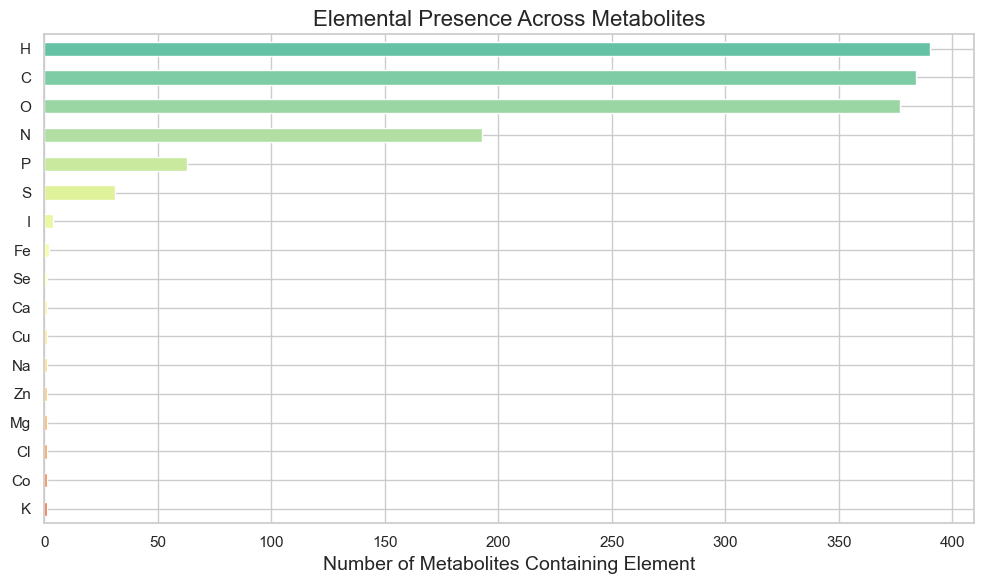


=== Heteroatom/Metal-Containing Metabolites ===
  S: 31 metabolites (7.7%)
  N: 193 metabolites (48.0%)
  P: 63 metabolites (15.7%)
  Cl: 1 metabolites (0.2%)
  I: 4 metabolites (1.0%)
  Se: 1 metabolites (0.2%)
  Fe: 2 metabolites (0.5%)
  Zn: 1 metabolites (0.2%)
  Cu: 1 metabolites (0.2%)
  Co: 1 metabolites (0.2%)


In [247]:
def parse_formula(formula):
    """Extract element counts from a chemical formula string."""
    if pd.isna(formula):
        return {}
    elements = re.findall(r'([A-Z][a-z]?)(\d*)', str(formula))
    return {el: int(count) if count else 1 for el, count in elements if el}

parsed = df['CHEMICAL_FORMULA'].apply(parse_formula)
all_elements = set()
for d in parsed:
    all_elements.update(d.keys())

# Count presence of each element
element_presence = {el: sum(1 for d in parsed if el in d) for el in all_elements}
element_series = pd.Series(element_presence).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
element_series.plot.barh(color=plt.cm.Spectral(np.linspace(0.2, 0.8, len(element_series))))
plt.xlabel('Number of Metabolites Containing Element')
plt.title('Elemental Presence Across Metabolites')
plt.tight_layout()
plt.show()

# Heteroatom analysis
heteroatoms = ['S', 'N', 'P', 'Cl', 'Br', 'I', 'Se', 'Fe', 'Zn', 'Cu', 'Co', 'Mn']
print('\n=== Heteroatom/Metal-Containing Metabolites ===')
for el in heteroatoms:
    count = element_presence.get(el, 0)
    if count > 0:
        print(f'  {el}: {count} metabolites ({count/len(df)*100:.1f}%)')

#### 🧬 TME Signaling & Cancer Connectome Insights:
- **Sulfur (S) — Present in ~7.7% of Metabolites**
  - **Redox Protection:** Extracellular Cysteine/Glutathione shuttle (protects cancer cells from ferroptosis/chemo).
  - **Gasotransmitters:** Hydrogen sulfide ($H_2S$) autocrine loops (promotes vascular remodeling).
- **Nitrogen (N) — Present in ~48.1% of Metabolites**
  - **Purinergic Signaling:** Adenosine $\rightarrow$ **$A_{2A}R$ / $A_{2B}R$** (primary T-cell/NK cell "off-switch").
  - **Amino Acid Exhaustion:** Kynurenine $\rightarrow$ **AHR** (drives $T_{reg}$ differentiation & tolerogenic dendritic cells).
- **Phosphorus (P) — Present in ~15.7% of Metabolites**
  - **Inflammatory DAMPs:** Extracellular ATP $\rightarrow$ **P2RX7 / P2RY** (triggers inflammasome & cell recruitment).
  - **Bioactive Lipids:** S1P & LPA $\rightarrow$ **S1PR1-5 / LPAR1-6** (orchestrates angiogenesis & cell migration).
- **Halogens (Cl, I) — Present in ~1.2% of Metabolites**
  - **Endocrine Regulators:** Thyroid hormones (T3/T4) $\rightarrow$ **$\alpha v\beta 3$ Integrin** (stimulates proliferation).
  - **Ion Shifts:** Extracellular Chloride shifts via GABA/Glutamate pathways (controls glioblastoma migration).
- **Selenium (Se) — Present in ~0.2% of Metabolites**
  - **ROS Modulators:** Selenoproteins (e.g., extracellular GPX) $\rightarrow$ alters ROS-mediated metastatic cascades.
- **Transition Metals (Fe, Zn, Cu, Co) — Present in ~1.1% of Metabolites**
  - **Iron (Fe):** Iron competition in TME $\rightarrow$ macrophage polarization (M1 vs M2) & ferroptosis.
  - **Copper (Cu):** **LOX** catalytic co-factor $\rightarrow$ crosslinks collagen to establish pre-metastatic niches.
  - **Zinc (Zn):** **MMP** zinc-finger engine $\rightarrow$ basement membrane degradation for cell invasion.
- **Carbon (C), Hydrogen (H), Oxygen (O) — Organic Scaffold**
  - **Lactate Pathway:** Lactate $\rightarrow$ **GPR81** (drives acidification, angiogenesis, & immune evasion).
  - **Lipid Mediators:** Prostaglandins (e.g., $PGE_2$) $\rightarrow$ **EP2/EP4 GPCRs** (mediates T-cell suppression).

### 6.4. Molecular Weight Classes & Communication Modes

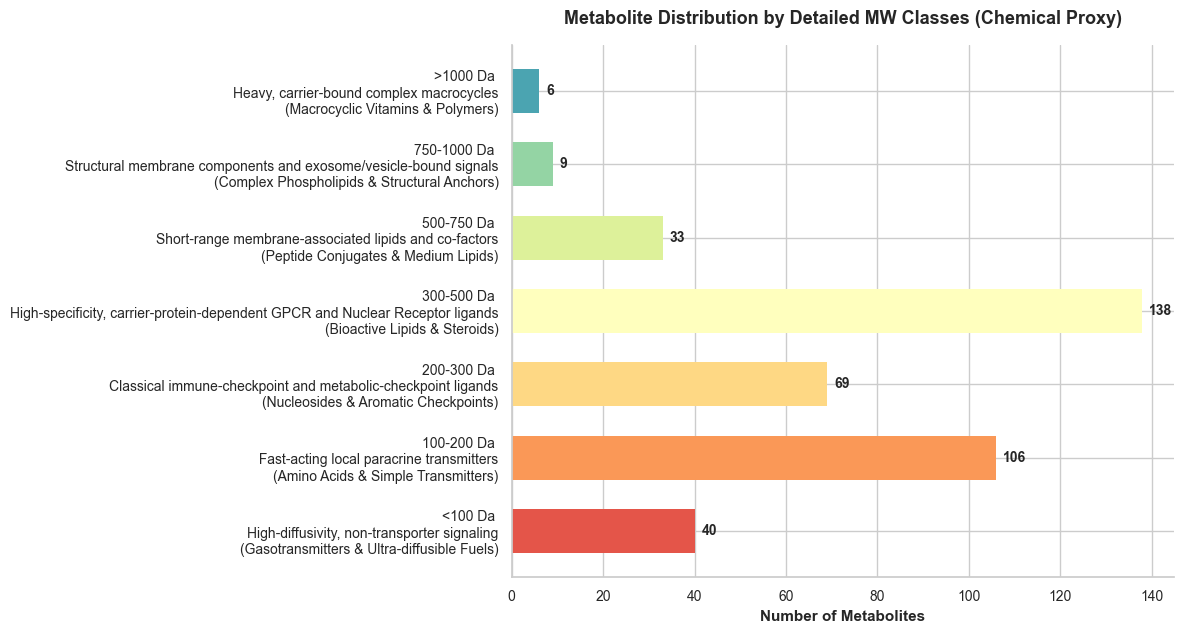

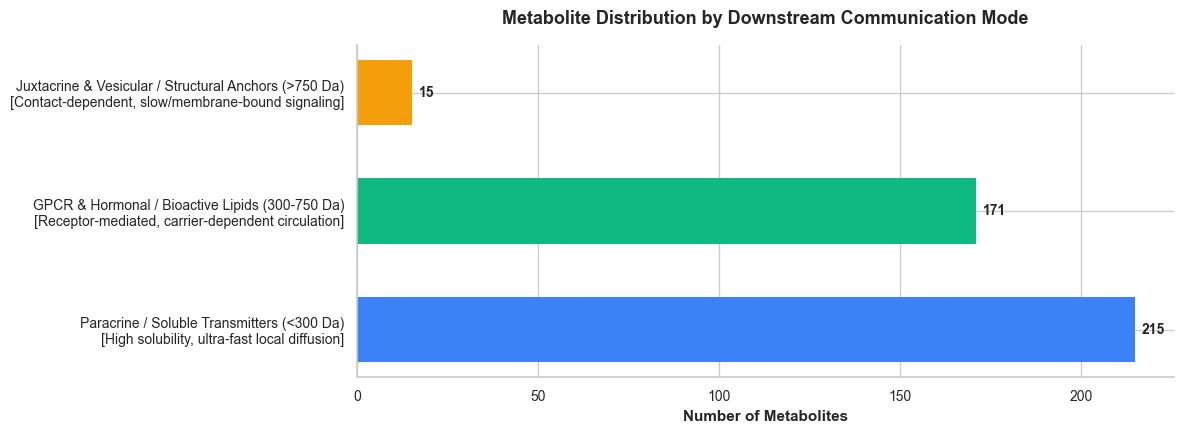


=== Database Breakdown by MW Class ===
  <100 Da (40 metabs): {'Cellinker2': 28, 'MRCLinkDB': 28, 'MEBOCOST': 25, 'MetaLigand': 24, 'scCellFie': 5, 'CellPhoneDBv5': 1}
  100-200 Da (106 metabs): {'MetaLigand': 77, 'MEBOCOST': 63, 'Cellinker2': 63, 'MRCLinkDB': 63, 'scCellFie': 33, 'CellPhoneDBv5': 10}
  200-300 Da (69 metabs): {'Cellinker2': 45, 'MRCLinkDB': 45, 'MEBOCOST': 42, 'MetaLigand': 38, 'scCellFie': 19, 'CellPhoneDBv5': 8}
  300-500 Da (138 metabs): {'MetaLigand': 89, 'Cellinker2': 88, 'MRCLinkDB': 88, 'MEBOCOST': 76, 'CellPhoneDBv5': 27, 'scCellFie': 16}
  500-750 Da (33 metabs): {'scCellFie': 17, 'Cellinker2': 15, 'MRCLinkDB': 15, 'MetaLigand': 14, 'MEBOCOST': 13, 'CellPhoneDBv5': 3}
  750-1000 Da (9 metabs): {'scCellFie': 7, 'MetaLigand': 2, 'Cellinker2': 2, 'MRCLinkDB': 2, 'CellPhoneDBv5': 1, 'MEBOCOST': 1}
  >1000 Da (6 metabs): {'Cellinker2': 2, 'MRCLinkDB': 2, 'scCellFie': 2, 'MEBOCOST': 1, 'CellPhoneDBv5': 1, 'MetaLigand': 1}


In [248]:
# 1. Define bins and labels for detailed MW Classes
bins_mw = [0, 100, 200, 300, 500, 750, 1000, float('inf')]
labels_mw = ['<100', '100-200', '200-300', '300-500', '500-750', '750-1000', '>1000']
plot_labels_mw = [
    '<100 Da \nHigh-diffusivity, non-transporter signaling\n(Gasotransmitters & Ultra-diffusible Fuels)',
    '100-200 Da \n Fast-acting local paracrine transmitters\n(Amino Acids & Simple Transmitters)',
    '200-300 Da \nClassical immune-checkpoint and metabolic-checkpoint ligands\n(Nucleosides & Aromatic Checkpoints)',
    '300-500 Da \nHigh-specificity, carrier-protein-dependent GPCR and Nuclear Receptor ligands\n(Bioactive Lipids & Steroids)',
    '500-750 Da \nShort-range membrane-associated lipids and co-factors\n(Peptide Conjugates & Medium Lipids)',
    '750-1000 Da \nStructural membrane components and exosome/vesicle-bound signals\n(Complex Phospholipids & Structural Anchors)',
    '>1000 Da \nHeavy, carrier-bound complex macrocycles\n(Macrocyclic Vitamins & Polymers)'
]

df['MW_Class'] = pd.cut(df['AVERAGE_MASS'], bins=bins_mw, labels=labels_mw, right=False)
mw_counts = df['MW_Class'].value_counts().reindex(labels_mw)

# Plot 1: Detailed MW Classes (Horizontal Bar for Readability of Long Labels)
fig, ax = plt.subplots(figsize=(12, 6.5))
colors_mw = plt.cm.Spectral(np.linspace(0.15, 0.85, len(labels_mw)))
bars_mw = ax.barh(plot_labels_mw, mw_counts.values, color=colors_mw, edgecolor='none', height=0.6)

ax.set_xlabel('Number of Metabolites', fontsize=11, fontweight='semibold')
ax.set_title('Metabolite Distribution by Detailed MW Classes (Chemical Proxy)', fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='both', which='major', labelsize=10)

# Add values at the end of each bar
for b in bars_mw:
    width = b.get_width()
    if width > 0:
        ax.annotate(f'{int(width)}',
                    xy=(width, b.get_y() + b.get_height() / 2),
                    xytext=(5, 0),  # 5 points horizontal offset
                    textcoords="offset points",
                    ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Define bins and labels for high-level Communication Modes (The Peaks)
bins_comm = [0, 300, 750, float('inf')]
labels_comm = ['Paracrine', 'GPCR/Hormonal', 'Juxtacrine/Vesicular']
plot_labels_comm = [
    'Paracrine / Soluble Transmitters (<300 Da)\n[High solubility, ultra-fast local diffusion]',
    'GPCR & Hormonal / Bioactive Lipids (300-750 Da)\n[Receptor-mediated, carrier-dependent circulation]',
    'Juxtacrine & Vesicular / Structural Anchors (>750 Da)\n[Contact-dependent, slow/membrane-bound signaling]'
]

df['Comm_Mode'] = pd.cut(df['AVERAGE_MASS'], bins=bins_comm, labels=labels_comm, right=False)
comm_counts = df['Comm_Mode'].value_counts().reindex(labels_comm)

# Plot 2: High-Level Communication Modes (Horizontal Bar)
fig, ax = plt.subplots(figsize=(12, 4.5))
colors_comm = ['#3b82f6', '#10b981', '#f59e0b']  # Sleek modern blue, emerald, amber palette
bars_comm = ax.barh(plot_labels_comm, comm_counts.values, color=colors_comm, edgecolor='none', height=0.55)

ax.set_xlabel('Number of Metabolites', fontsize=11, fontweight='semibold')
ax.set_title('Metabolite Distribution by Downstream Communication Mode', fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='both', which='major', labelsize=10)

# Add values at the end of each bar
for b in bars_comm:
    width = b.get_width()
    if width > 0:
        ax.annotate(f'{int(width)}',
                    xy=(width, b.get_y() + b.get_height() / 2),
                    xytext=(5, 0),  # 5 points horizontal offset
                    textcoords="offset points",
                    ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Database Breakdown by MW Class for granular tracking
print('\n=== Database Breakdown by MW Class ===')
for mw_label in labels_mw:
    subset = df[df['MW_Class'] == mw_label]
    if len(subset) > 0:
        dbs = subset['database'].str.split(', ').explode().value_counts()
        print(f'  {mw_label} Da ({len(subset)} metabs): {dbs.to_dict()}')

# Cleanup temporary columns
df.drop(columns=['MW_Class', 'Comm_Mode'], inplace=True)


## 7. Confidence Tiers for Downstream Analysis

Assigning a confidence tier based on cross-database validation and annotation completeness. This provides a prioritization framework for selecting metabolites for downstream cell-cell communication (CCC) analysis.

| Confidence Tier | Database Overlap Criterion | Structural Requirements | Biological Signaling Significance |
| :--- | :--- | :--- | :--- |
| **Tier 1 (High)** | Overlap in $\ge$ 4 databases | Both SMILES & Average Mass present | High-confidence, widely cross-validated extracellular signaling ligands |
| **Tier 2 (Medium)** | Overlap in 2-3 databases | SMILES present | Moderately validated signaling metabolites |
| **Tier 3 (Low)** | Found in exactly 1 database | Any | Single-source, unvalidated metabolites (highly unique to specific platforms) |

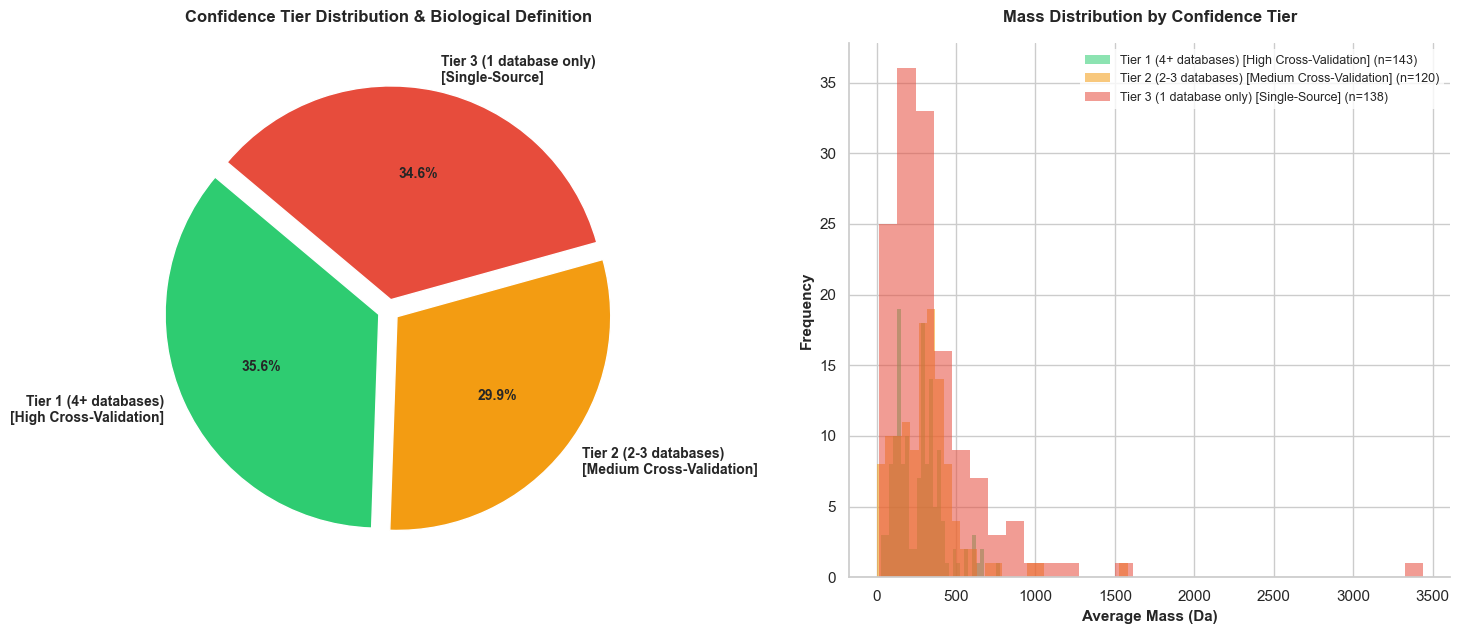


=== Confidence Tier Summary ===
  * Tier 1 (High - Overlap in 4+ databases, widely cross-validated): 143 metabolites (35.6%)
  * Tier 2 (Medium - Overlap in 2-3 databases, mainly Cellinker2/MRCLinkDB): 120 metabolites (29.9%)
  * Tier 3 (Low - Found in only 1 database, mainly MetaLigand/scCellFie): 139 metabolites (34.6%)

→ Tier 1 metabolites are recommended as the primary high-confidence set for TCGA/scRNAseq integration.


In [249]:
# 1. Assign Tiers based on strict multi-database overlap and structure completeness
def assign_tier(row):
    score = row['databases_count']
    has_smiles = pd.notna(row['SMILES'])
    has_mass = pd.notna(row['AVERAGE_MASS'])
    if score >= 4 and has_smiles and has_mass:
        return 'Tier 1 (High)'
    elif score >= 2 and has_smiles:
        return 'Tier 2 (Medium)'
    else:
        return 'Tier 3 (Low)'

df['Confidence_Tier'] = df.apply(assign_tier, axis=1)
tier_counts = df['Confidence_Tier'].value_counts()

# 2. Audit each tier dynamically to extract structural and source properties
tier_info = {}
for tier_name in ['Tier 1 (High)', 'Tier 2 (Medium)', 'Tier 3 (Low)']:
    sub = df[df['Confidence_Tier'] == tier_name]
    n = len(sub)
    pct = (n / len(df)) * 100
    
    # Database overlap details
    dbs_sorted = sub['database'].str.split(', ').explode().value_counts()
    top_dbs = "/".join(dbs_sorted.head(2).index)
    
    if tier_name == 'Tier 1 (High)':
        desc = f"Tier 1 (High - Overlap in 4+ databases, widely cross-validated): {n} metabolites ({pct:.1f}%)"
        short_label = f"Tier 1 (4+ databases)\n[High Cross-Validation]"
    elif tier_name == 'Tier 2 (Medium)':
        desc = f"Tier 2 (Medium - Overlap in 2-3 databases, mainly {top_dbs}): {n} metabolites ({pct:.1f}%)"
        short_label = f"Tier 2 (2-3 databases)\n[Medium Cross-Validation]"
    else:
        desc = f"Tier 3 (Low - Found in only 1 database, mainly {top_dbs}): {n} metabolites ({pct:.1f}%)"
        short_label = f"Tier 3 (1 database only)\n[Single-Source]"
        
    tier_info[tier_name] = {
        'count': n,
        'pct': pct,
        'desc': desc,
        'short_label': short_label,
        'masses': sub['AVERAGE_MASS'].dropna()
    }

# 3. Create plotting visualization with detailed descriptions
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# Slice mapping for the pie chart
labels_pie = [tier_info[t]['short_label'] for t in ['Tier 1 (High)', 'Tier 2 (Medium)', 'Tier 3 (Low)']]
counts_pie = [tier_info[t]['count'] for t in ['Tier 1 (High)', 'Tier 2 (Medium)', 'Tier 3 (Low)']]
tier_colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[0].pie(counts_pie, labels=labels_pie, autopct='%1.1f%%',
            colors=tier_colors, startangle=140, explode=[0.05]*3,
            textprops={'fontsize': 10, 'weight': 'bold'})
axes[0].set_title('Confidence Tier Distribution & Biological Definition', fontsize=12, fontweight='bold', pad=15)

# Mass distribution histogram by tier
for i, tier in enumerate(['Tier 1 (High)', 'Tier 2 (Medium)', 'Tier 3 (Low)']):
    masses = tier_info[tier]['masses']
    if len(masses) > 0:
        clean_label = tier_info[tier]['short_label'].replace('\n', ' ')
        axes[1].hist(masses, bins=30, alpha=0.55, 
                     label=f"{clean_label} (n={len(masses)})", 
                     color=tier_colors[i], edgecolor='none')
                     
axes[1].set_xlabel('Average Mass (Da)', fontsize=11, fontweight='semibold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='semibold')
axes[1].set_title('Mass Distribution by Confidence Tier', fontsize=12, fontweight='bold', pad=15)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_color('#cccccc')
axes[1].spines['bottom'].set_color('#cccccc')
axes[1].legend(frameon=True, facecolor='white', edgecolor='none', fontsize=9)

plt.tight_layout()
plt.show()

# 4. Print beautiful, explicit summary of the tiers
print('\n=== Confidence Tier Summary ===')
for tier in ['Tier 1 (High)', 'Tier 2 (Medium)', 'Tier 3 (Low)']:
    print(f"  * {tier_info[tier]['desc']}")

print(f'\n→ Tier 1 metabolites are recommended as the primary high-confidence set for TCGA/scRNAseq integration.')

# Cleanup


---

## 8. Summary Table: Key Metabolite Catalog Statistics

In [250]:
summary = {
    'Total unique metabolites': len(df),
    'With HMDB ID': df['HMDB_ID'].notna().sum(),
    'With SMILES': df['SMILES'].notna().sum(),
    'With chemical formula': df['CHEMICAL_FORMULA'].notna().sum(),
    'Median mass (Da)': f"{df['AVERAGE_MASS'].median():.1f}",
    'In 1 database only': (df['databases_count'] == 1).sum(),
    'In 2+ databases': (df['databases_count'] >= 2).sum(),
    'In 3+ databases (high confidence)': (df['databases_count'] >= 3).sum(),
    'In all 6 databases': (df['databases_count'] == 6).sum(),
}
pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])

,Value
Total unique metabolites,402
With HMDB ID,402
With SMILES,402
With chemical formula,402
Median mass (Da),286.5
In 1 database only,139
In 2+ databases,263
In 3+ databases (high confidence),221
In all 6 databases,10


---

## 9. High-Confidence Tier 1 and Tier 2 Metabolites Export

Extracting and exporting the highly cross-validated Tier 1 metabolites for downstream cell-cell communication (CCC) target-pair mapping.

In [251]:
# 1. Extract Tier 1 (High Confidence) metabolites
df_tier1 = df[df['Confidence_Tier'] == 'Tier 1 (High)'].copy()

# 2. Define the output file path
output_path = '../output/human_database_merge_unique_metab_tier1.csv'

# 3. Save the high-confidence dataset
df_tier1.to_csv(output_path, index=False)

print(f"🎉 Successfully exported {len(df_tier1)} high-confidence Tier 1 metabolites to:")
print(f"   -> '{output_path}'")

# 4. Display the top 15 Tier 1 metabolites as a catalog preview
df_preview = df_tier1[['Metabolite_Name', 'HMDB_Name', 'databases_count', 'SMILES', 'AVERAGE_MASS']].head(15)
df_preview


🎉 Successfully exported 143 high-confidence Tier 1 metabolites to:
   -> '../output/human_database_merge_unique_metab_tier1.csv'


,Metabolite_Name,HMDB_Name,databases_count,SMILES,AVERAGE_MASS
7,12-hydroxyeicosatetraenoic acid,12-HETE,4,CCCCC\C=C/C[C@H](O)\C=C\C=C/C\C=C/CCCC(O)=O,320.4663
10,13-cis-retinoic acid,13-cis-Retinoic acid,4,C\C(\C=C\C1=C(C)CCCC1(C)C)=C/C=C/C(/C)=C\C(O)=O,300.4351
18,2-arachidonoylglycerol,"MG(0:0/20:4(5Z,8Z,11Z,14Z)/0:0)",5,[H]C(CO)(CO)OC(=O)CCC\C=C/C\C=C/C\C=C/C\C=C/CCCCC,378.5454
19,2-hydroxyestradiol,2-Hydroxyestradiol,4,[H][C@@]12CC[C@H](O)[C@@]1(C)CC[C@]1([H])C3=C(...,288.3814
24,20-hydroxy-leukotriene b4,20-Hydroxy-leukotriene B4,4,OCCCCC\C=C/C[C@@H](O)\C=C\C=C\C=C/[C@@H](O)CCC...,352.4651
27,24-hydroxycholesterol,24-Hydroxycholesterol,4,[H][C@@]1(CC[C@@]2([H])[C@]3([H])CC=C4C[C@@H](...,402.6529
28,25-hydroxycholesterol,25-Hydroxycholesterol,4,[H]C12CC[C@H]([C@H](C)CCCC(C)(C)O)[C@@]1(C)CCC...,402.6529
29,27-hydroxycholesterol,27-Hydroxycholesterol,4,[H][C@@]1(CC[C@@]2([H])[C@]3([H])CC=C4C[C@@H](...,402.6529
34,3-methoxytyramine,3-Methoxytyramine,4,COC1=C(O)C=CC(CCN)=C1,167.2050
38,5(s)-hydroperoxyeicosatetraenoic acid,5(S)-Hydroperoxyeicosatetraenoic acid,5,CCCCC\C=C/C\C=C/C\C=C/C=C/[C@H](CCCC(O)=O)OO,336.4657


In [252]:
# 1. Extract Tier 1 (High Confidence) metabolites
df_tier2 = df[df['Confidence_Tier'] == 'Tier 2 (Medium)'].copy()

# 2. Define the output file path
output_path = '../output/human_database_merge_unique_metab_tier2.csv'

# 3. Save the high-confidence dataset
df_tier2.to_csv(output_path, index=False)

print(f"🎉 Successfully exported {len(df_tier1)} medium-confidence Tier 2 metabolites to:")
print(f"   -> '{output_path}'")

# 4. Display the top 15 Tier 1 metabolites as a catalog preview
df_preview = df_tier2[['Metabolite_Name', 'HMDB_Name', 'databases_count', 'SMILES', 'AVERAGE_MASS']].head(15)
df_preview


🎉 Successfully exported 143 medium-confidence Tier 2 metabolites to:
   -> '../output/human_database_merge_unique_metab_tier2.csv'


,Metabolite_Name,HMDB_Name,databases_count,SMILES,AVERAGE_MASS
0,(r)-5-diphosphomevalonic acid,(R)-5-Diphosphomevalonic acid,3,C[C@@](O)(CCOP(O)(=O)OP(O)(O)=O)CC(O)=O,308.1169
2,"1,25-dihydroxyvitamin d3-26,23-lactone","1,25-Dihydroxyvitamin D3-26,23-lactone",2,[H][C@@]1(CC[C@@]2([H])\C(CCC[C@]12C)=C\C=C1\C...,444.6035
4,11-cis-retinol,11-cis-Retinol,3,C\C(=C/CO)\C=C/C=C(\C)/C=C/C1=C(C)CCCC1(C)C,286.4516
6,12(s)-leukotriene b4,12(S)-Leukotriene B4,2,CCCCC\C=C/C[C@H](O)\C=C\C=C\C=C/[C@@H](O)CCCC(...,336.4657
8,12-oxo-leukotriene b4,12-Keto-leukotriene B4,2,CCCCC\C=C/CC(=O)\C=C\C=C\C=C/[C@@H](O)CCCC(O)=O,334.4498
9,12s-hydroxyheptadecatrienoic acid,12S-HHT,3,CCCCC[C@H](O)\C=C\C=C\C\C=C/CCCC(O)=O,280.4024
12,"15-deoxy-d-12,14-prostaglandin j2","15-Deoxy-d-12,14-PGJ2",3,CCCCC\C=C\C=C1/[C@@H](C\C=C/CCCC(O)=O)C=CC1=O,316.4345
14,15-hydroxyeicosatetraenoic acid,15-HETE,3,CCCCC[C@H](O)\C=C\C=C/C\C=C/C\C=C/CCCC(O)=O,320.4663
25,20-hydroxyeicosatetraenoic acid,20-Hydroxyeicosatetraenoic acid,2,OCCCCC\C=C/C\C=C/C\C=C/C\C=C/CCCC(O)=O,320.4663
26,22b-hydroxycholesterol,22b-Hydroxycholesterol,3,[H][C@@]12CC[C@H]([C@H](C)[C@H](O)CCC(C)C)[C@@...,402.6529


---

## 10. Export Full Notebook Report to HTML

Compiling this entire interactive notebook—including all structured explanations, executable code blocks, data tables, and high-resolution plots—into a single publication-ready and highly interactive HTML report.

In [253]:
# ==========================================
# 📄 FULL NOTEBOOK HTML REPORT EXPORT
# ==========================================
if 'SAVE_AS_HTML' in globals() and SAVE_AS_HTML:
    import subprocess
    import os
    
    notebook_filename = 'unique_metab_data_exploration.ipynb'
    output_html = '../output/unique_metab_data_exploration_full_report.html'
    
    print(f"Executing full notebook HTML export for '{notebook_filename}'...")
    
    # Export to beautiful styled HTML
    print("Generating gorgeous, styling-preserved HTML report...")
    cmd_html = [
        'jupyter', 'nbconvert', '--to', 'html', 
        notebook_filename, '--output', output_html
    ]
    res_html = subprocess.run(cmd_html, capture_output=True, text=True)
    
    if res_html.returncode == 0:
        print(f"🎉 SUCCESS: Notebook successfully exported as a styled HTML report!")
        print(f"   -> Saved to: '{output_html}'")
        print("\n💡 Tip: You can open this HTML file in any web browser to view, share, or print to PDF (Cmd+P)!")
    else:
        print("❌ HTML export failed. Error details:")
        print(res_html.stderr)
else:
    print("Full notebook HTML export is currently disabled. Set SAVE_AS_HTML = True in parameters at the top to compile the report!")

Executing full notebook HTML export for 'unique_metab_data_exploration.ipynb'...
Generating gorgeous, styling-preserved HTML report...
🎉 SUCCESS: Notebook successfully exported as a styled HTML report!
   -> Saved to: '../output/unique_metab_data_exploration_full_report.html'

💡 Tip: You can open this HTML file in any web browser to view, share, or print to PDF (Cmd+P)!
